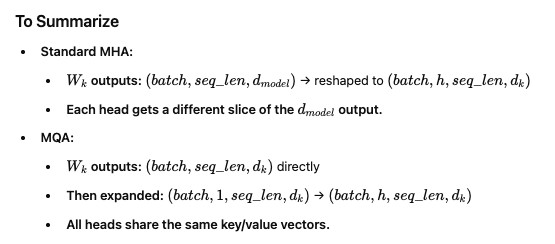

In [ ]:
"""
Summary:
    This script implements Multi-Query Attention (MQA) with a controllable parameter g.
    In MQA, the query is computed per head (as in standard Multi-Head Attention), but the key and value
    projections are computed only once per group (shared across h//g heads). This reduces memory and
    computational costs.
    
Shape transformations (including batch dimension):

1. Input:
    - q, k, v: (batch, seq_len, d_model)

2. After linear projections:
    - Query via W_q: (batch, seq_len, d_model)
    - Key via W_k:   (batch, seq_len, g * d_k)  where d_k = d_model // h
    - Value via W_v: (batch, seq_len, g * d_k)

3. Reshaping Query:
    - Reshape: (batch, seq_len, d_model) → (batch, seq_len, h, d_k)
    - Transpose: (batch, seq_len, h, d_k) → (batch, h, seq_len, d_k)

4. Processing Key/Value:
    - Reshape Key/Value: (batch, seq_len, g * d_k) → (batch, seq_len, g, d_k)
    - Expand: For each group, replicate each key/value to cover (h // g) heads:
         (batch, seq_len, g, d_k) → (batch, seq_len, h, d_k)
    - Transpose: (batch, seq_len, h, d_k) → (batch, h, seq_len, d_k)

5. Attention Computation:
    - Dot-product for each head:
         Query: (batch, h, seq_len, d_k)
         Keyᵀ:  (batch, h, d_k, seq_len)
         → Attention scores: (batch, h, seq_len, seq_len)
    - Softmax over last dimension; weighted sum with Value gives:
         (batch, h, seq_len, d_k)

6. Reassemble Heads:
    - Transpose: (batch, h, seq_len, d_k) → (batch, seq_len, h, d_k)
    - Reshape: (batch, seq_len, h, d_k) → (batch, seq_len, d_model)
    - Final linear projection: (batch, seq_len, d_model) → (batch, seq_len, d_model)

Example usage:
    q, k, v = torch.randn(batch, seq_len, d_model)
    mask = torch.ones(batch, 1, seq_len, seq_len)
    # With g=1, all heads share the same key/value projections.
    mqa = MultiQueryAttentionBlock(d_model=512, h=8, dropout=0.1, g=1)
    output = mqa(q, k, v, mask)
"""

import math
import torch
import torch.nn as nn
from typing import Optional, Tuple

class MultiQueryAttentionBlock(nn.Module):
    def __init__(self, d_model: int, h: int, dropout: float, g: int = 1) -> None:
        """
        Initialize the Multi-Query Attention Block with parameter g controlling groups.
        
        Args:
            d_model (int): Embedding dimension.
            h (int): Number of attention heads.
            dropout (float): Dropout probability.
            g (int): Number of groups for key/value projections.
                     For MQA, g=1 means a single set of key/value shared across all heads.
                     If g > 1, then keys/values are computed for each group and shared among h//g heads.
        """
        super().__init__()
        self.d_model: int = d_model
        self.h: int = h
        self.g: int = g  # number of groups
        assert d_model % h == 0, "d_model must be divisible by h"
        self.d_k: int = d_model // h  # dimension per head

        # Query projection remains standard: output dimension d_model, then split into h heads.
        self.w_q: nn.Linear = nn.Linear(d_model, d_model, bias=False)
        # For key and value, output dimension is g * d_k.
        self.w_k: nn.Linear = nn.Linear(d_model, g * self.d_k, bias=False)
        self.w_v: nn.Linear = nn.Linear(d_model, g * self.d_k, bias=False)
        
        # Output linear projection.
        self.w_o: nn.Linear = nn.Linear(d_model, d_model, bias=False)
        self.dropout: nn.Dropout = nn.Dropout(dropout)
    
    @staticmethod
    def attention(query: torch.Tensor,
                  key: torch.Tensor,
                  value: torch.Tensor,
                  mask: Optional[torch.Tensor],
                  dropout: nn.Dropout) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute scaled dot-product attention.
        
        Args:
            query (Tensor): Shape (batch, h, seq_len, d_k)
            key (Tensor): Shape (batch, h, seq_len, d_k)
            value (Tensor): Shape (batch, h, seq_len, d_k)
            mask (Tensor): Shape (batch, 1, seq_len, seq_len)
            dropout (nn.Dropout): Dropout layer.
            
        Returns:
            Tuple[Tensor, Tensor]:
                - Output tensor: (batch, h, seq_len, d_k)
                - Attention scores: (batch, h, seq_len, seq_len)
        """
        d_k = query.size(-1)
        # Dot product: (batch, h, seq_len, d_k) x (batch, h, d_k, seq_len) → (batch, h, seq_len, seq_len)
        attention_scores = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, -1e9)
        attention_scores = attention_scores.softmax(dim=-1)
        if dropout is not None:
            attention_scores = dropout(attention_scores)
        # Weighted sum with value: (batch, h, seq_len, seq_len) x (batch, h, seq_len, d_k) → (batch, h, seq_len, d_k)
        output = attention_scores @ value
        return output, attention_scores
    
    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: Optional[torch.Tensor]) -> torch.Tensor:
        """
        Forward pass for Multi-Query Attention.
        
        Args:
            q (Tensor): Query tensor of shape (batch, seq_len, d_model)
            k (Tensor): Key tensor of shape (batch, seq_len, d_model)
            v (Tensor): Value tensor of shape (batch, seq_len, d_model)
            mask (Tensor): Attention mask of shape (batch, 1, seq_len, seq_len)
            
        Returns:
            Tensor: Output tensor of shape (batch, seq_len, d_model)
        """
        batch, seq_len, _ = q.size()
        
        # 1. Compute query projection:
        # (batch, seq_len, d_model) -> (batch, seq_len, d_model)
        query = self.w_q(q)
        # Reshape query: (batch, seq_len, d_model) → (batch, seq_len, h, d_k) → (batch, h, seq_len, d_k)
        query = query.view(batch, seq_len, self.h, self.d_k).transpose(1, 2)
        
        # 2. Compute key and value projections in groups:
        #    Using shared parameters across groups.
        #    (batch, seq_len, d_model) * (dmodel, g * d_k) -> (batch, seq_len, g * d_k)
        key = self.w_k(k)
        value = self.w_v(v)
        # Reshape: (batch, seq_len, g * d_k) → (batch, seq_len, g, d_k)
        key = key.view(batch, seq_len, self.g, self.d_k)
        value = value.view(batch, seq_len, self.g, self.d_k)
        
        # 3. Expand key/value to match the number of heads:
        #    Each group is shared by (h // g) heads.
        head_per_group = self.h // self.g  # must be an integer, in our case of MQA g=1
        # Add a dimension for head replication:
        # (batch, seq_len, g, d_k) → (batch, seq_len, 1, g, d_k)
        key = key.unsqueeze(2)
        value = value.unsqueeze(2)
        # Expand along the new head dimension:
        # → (batch, seq_len, head_per_group, g, d_k)
        key = key.expand(-1, -1, head_per_group, -1, -1)
        value = value.expand(-1, -1, head_per_group, -1, -1)
        # Reshape to combine group heads:
        # (batch, seq_len, head_per_group, g, d_k) → (batch, seq_len, head_per_group * g, d_k)
        key = key.reshape(batch, seq_len, self.h, self.d_k)
        value = value.reshape(batch, seq_len, self.h, self.d_k)
        # Transpose to bring head dimension to the front:
        # (batch, seq_len, h, d_k) → (batch, h, seq_len, d_k)
        key = key.transpose(1, 2)
        value = value.transpose(1, 2)
        
        # 4. Compute attention:
        #    Query: (batch, h, seq_len, d_k)
        #    Key:   (batch, h, seq_len, d_k)
        #    Value: (batch, h, seq_len, d_k)
        x, self.attention_scores = MultiQueryAttentionBlock.attention(query, key, value, mask, self.dropout)
        
        # 5. Reassemble heads:
        #    Transpose: (batch, h, seq_len, d_k) → (batch, seq_len, h, d_k)
        #    Reshape: (batch, seq_len, h, d_k) → (batch, seq_len, h * d_k) = (batch, seq_len, d_model)
        x = x.transpose(1, 2).contiguous().view(batch, seq_len, self.h * self.d_k)
        
        # 6. Final linear projection:
        #    (batch, seq_len, d_model) → (batch, seq_len, d_model)
        return self.w_o(x)
